In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import gsw
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.cm as cm
import cartopy.crs as ccrs
from cartopy.mpl.ticker import (LongitudeFormatter, LatitudeFormatter,
                                LatitudeLocator)
import regionmask

from utilities import load_and_prepare_dataset

In [2]:
# SSTA combination correlation plot
correlations = {
    # Level 0: 0 parameters ON
    '00000': 0.07,

    # Level 1: 1 parameter ON
    '10000': 0.16, '01000': 0.14, '00100': 0.27, '00010': 0.07, '00001': 0.06,

    # Level 2: 2 parameters ON
    '11000': 0.18, '10100': 0.28, '10010': 0.17, '10001': 0.13,
    '01100': 0.25, '01010': 0.17, '01001': 0.15,
    '00110': 0.25, '00101': 0.20,
    '00011': 0.08,

    # Level 3: 3 parameters ON
    '11100': 0.27, '11010': 0.20, '11001': 0.18,
    '10110': 0.28, '10101': 0.23, '10011': 0.15,
    '01110': 0.27, '01101': 0.24, '01011': 0.17,
    '00111': 0.21,

    # Level 4: 4 parameters ON
    '11110': 0.29, '11101': 0.26, '11011': 0.20, '10111': 0.25, '01111': 0.26,

    # Level 5: 5 parameters ON
    '11111': 0.28
}
level0_sorted = ['00000']
level1_sorted = ['10000', '01000', '00100', '00010', '00001']
level2_sorted = ['11000', '10010', '10001', '10100', '01100', '00110', '00101', '01010', '01001', '00011']
level3_sorted = ['11100', '10110', '10101', '11010', '11001', '10011', '01011', '01110', '01101', '00111']
level4_sorted = ['11110', '11101', '11011', '10111', '01111']
level5_sorted = ['11111']

positions = {}
# Level 0: center
positions['00000'] = (4, 0)
# Level 1: x positions 0, 2, 4, 6, 8
for i, combo in enumerate(level1_sorted):
    positions[combo] = (i*2, 1)
# Level 2: 10 combinations, spaced evenly
for i, combo in enumerate(level2_sorted):
    positions[combo] = (i*8/9, 2)
# Level 3: 10 combinations, spaced evenly
for i, combo in enumerate(level3_sorted):
    positions[combo] = (i*8/9, 3)
# Level 4: 5 combinations, aligned with Level 1
for i, combo in enumerate(level4_sorted):
    positions[combo] = (i*2, 4)
# Level 5: center
positions['11111'] = (4, 5)


def combo_to_set(combo):
    """Convert combo string to set of parameter indices (0-4)"""
    return {i for i, b in enumerate(combo) if b == '1'}


def get_children(parent, lower_level):
    """Return all children of parent in the level below"""
    parent_set = combo_to_set(parent)
    children = []
    for child in lower_level:
        child_set = combo_to_set(child)
        # Child is a subset of parent AND has exactly one less element
        if child_set.issubset(parent_set) and len(child_set) == len(parent_set) - 1:
            children.append(child)
    return children

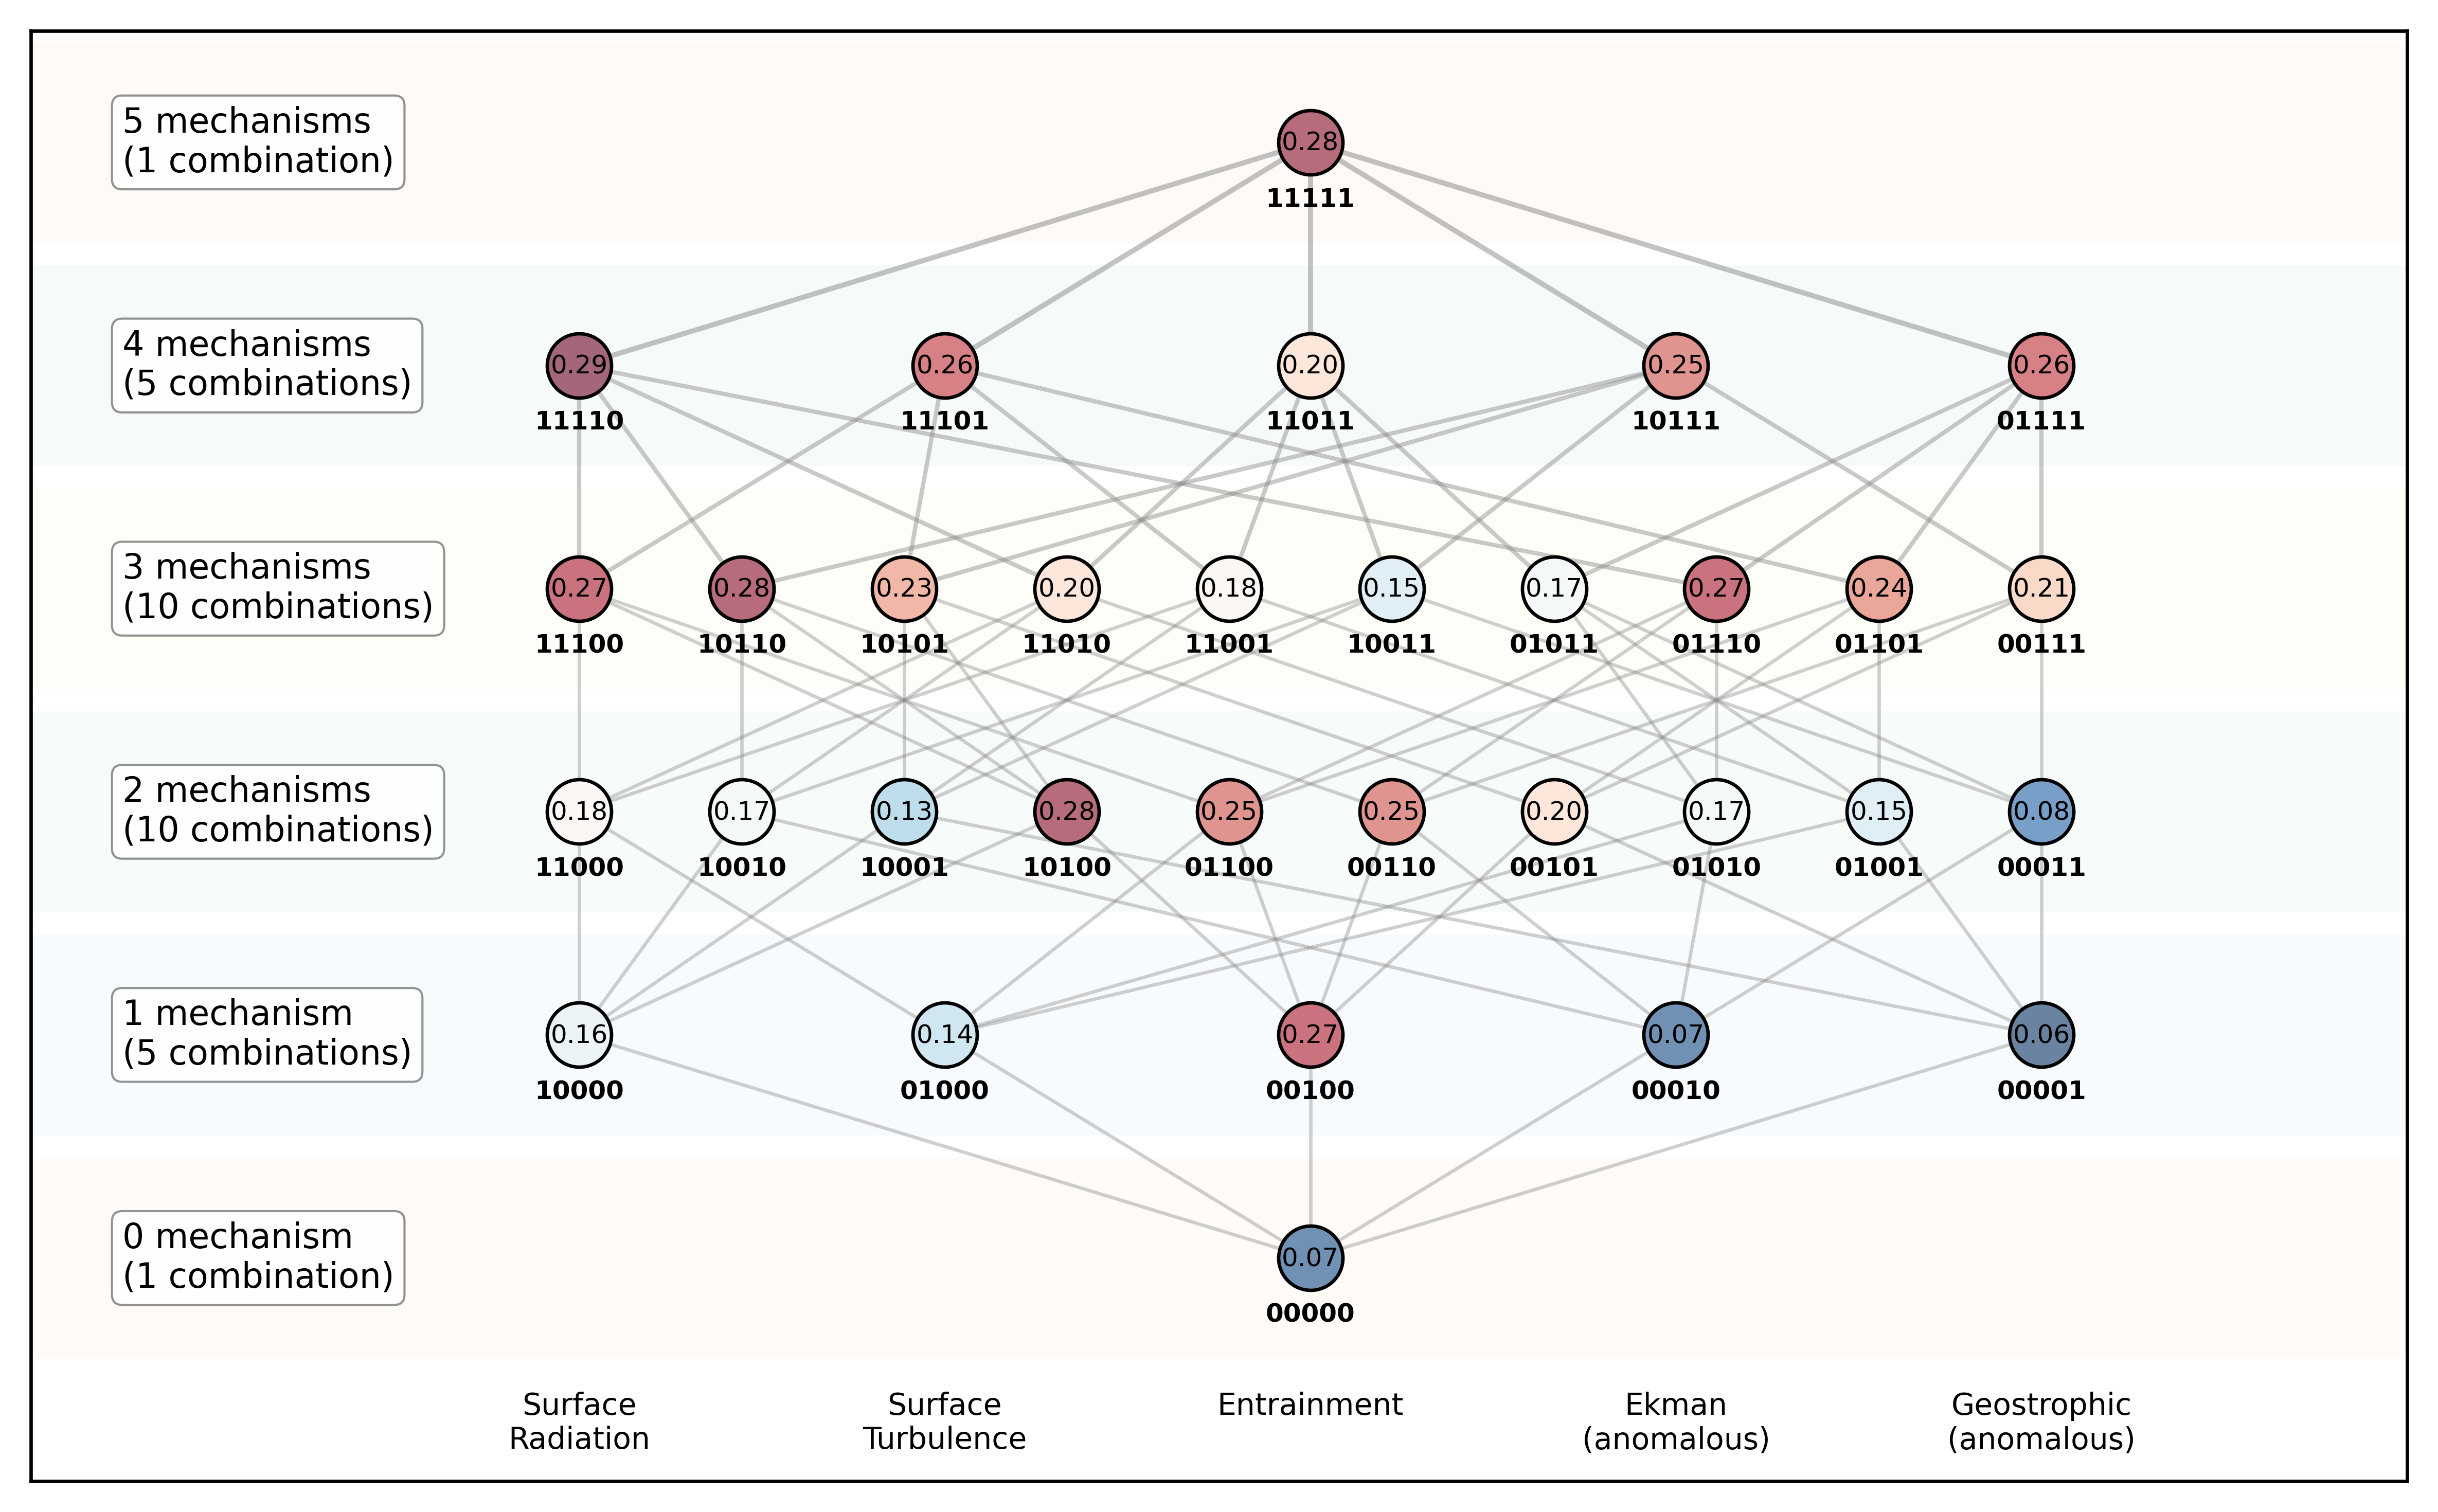

In [3]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=600)

level_facecolors = {
    0: '#FEF3E8',
    1: '#E8F4FC',
    2: '#E6F3EF',
    3: '#FEFCE8',
    4: '#E6F0F5',
    5: '#FDF0E8'
}
level_titles = {
    0: '0 mechanism\n(1 combination)',
    1: '1 mechanism\n(5 combinations)',
    2: '2 mechanisms\n(10 combinations)',
    3: '3 mechanisms\n(10 combinations)',
    4: '4 mechanisms\n(5 combinations)',
    5: '5 mechanisms\n(1 combination)'
}

# Level 5 -> Level 4
for parent in level5_sorted:
    children = get_children(parent, level4_sorted)
    px, py = positions[parent]
    for child in children:
        cx, cy = positions[child]
        ax.plot([px, cx], [py, cy], '#888888', linewidth=1.2, alpha=0.5, zorder=1)
# Level 4 -> Level 3
for parent in level4_sorted:
    children = get_children(parent, level3_sorted)
    px, py = positions[parent]
    for child in children:
        cx, cy = positions[child]
        ax.plot([px, cx], [py, cy], '#888888', linewidth=1.0, alpha=0.45, zorder=1)
# Level 3 -> Level 2
for parent in level3_sorted:
    children = get_children(parent, level2_sorted)
    px, py = positions[parent]
    for child in children:
        cx, cy = positions[child]
        ax.plot([px, cx], [py, cy], '#888888', linewidth=0.8, alpha=0.4, zorder=1)
# Level 2 -> Level 1
for parent in level2_sorted:
    children = get_children(parent, level1_sorted)
    px, py = positions[parent]
    for child in children:
        cx, cy = positions[child]
        ax.plot([px, cx], [py, cy], '#888888', linewidth=0.8, alpha=0.4, zorder=1)
# Level 1 -> Level 0
for parent in level1_sorted:
    children = get_children(parent, level0_sorted)
    px, py = positions[parent]
    for child in children:
        cx, cy = positions[child]
        ax.plot([px, cx], [py, cy], '#888888', linewidth=0.8, alpha=0.4, zorder=1)

tree = {
    0: level0_sorted, 1: level1_sorted,
    2: level2_sorted, 3: level3_sorted,
    4: level4_sorted, 5: level5_sorted
}

corr_values = list(correlations.values())
cmap = cm.RdBu_r
norm = plt.Normalize(vmin=min(corr_values), vmax=max(corr_values))


def lighten_color(corr, cmap, norm, factor=0.5):
    """Lighten a color based on its correlation value"""
    color = cmap(norm(corr))
    return tuple(1 - (1 - c) * factor for c in color)


for level, combos in tree.items():
    y = level
    for combo in combos:
        x, y_pos = positions[combo]
        corr = correlations[combo]

        ax.plot(x, y_pos, 'o', markersize=15, 
                color=lighten_color(corr, cmap, norm, factor=0.6),
                markeredgecolor='black', 
                markeredgewidth=0.8,
                zorder=3)

        ax.text(
            x, y_pos-0.2, combo, 
            ha='center', va='top', 
            fontsize=6, fontweight='bold'
        )
        
        ax.text(
            x, y_pos-0.06, f'{corr:.2f}', 
            ha='center', va='bottom', 
            fontsize=6
            )

for level in range(0, 6):
    y_band = level
    ax.axhspan(
        y_band - 0.45, y_band + 0.45, 
        facecolor=level_facecolors[level], 
        alpha=0.3, zorder=0
    )

for level, title in level_titles.items():
    y_pos = level
    ax.text(
        -2.5, y_pos, title,
        ha='left', va='center', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray', linewidth=0.5)
    )

ax.set_xlim(-3, 10)
ax.set_ylim(-1, 5.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
for x, label in zip([0, 2, 4, 6, 8], 
                    ['Surface\nRadiation', 'Surface\nTurbulence', 
                     'Entrainment',
                     'Ekman\n(anomalous)', 'Geostrophic\n(anomalous)']):
    ax.text(x, -0.6, label, ha='center', va='top', fontsize=7)

plt.tight_layout()
plt.show()

In [4]:
# SSSA combination correlation plot
correlations = {
    # Level 0: 0 parameters ON
    '0000': 0.05,

    # Level 1: 1 parameter ON
    '1000': 0.19, '0100': 0.55, '0010': 0.06, '0001': 0.05,

    # Level 2: 2 parameters ON
    '1100': 0.42, '1010': 0.20, '1001': 0.17,
    '0110': 0.44, '0101': 0.36,
    '0011': 0.06,

    # Level 3: 3 parameters ON
    '1110': 0.41, '1101': 0.35, '1011': 0.18,
    '0111': 0.34,

    # Level 4: 4 parameters ON
    '1111': 0.35
}
level0_sorted = ['0000']
level1_sorted = ['1000', '0100', '0010', '0001']
level2_sorted = ['1100', '0110', '0101', '1010', '1001', '0011']
level3_sorted = ['1110', '1101', '1011', '0111']
level4_sorted = ['1111']

positions = {}
# Level 0: center
positions['0000'] = (3, 0)
# Level 1: x positions 0, 2, 4, 6
for i, combo in enumerate(level1_sorted):
    positions[combo] = (i*2, 1)
# Level 2: 6 combinations, spaced evenly
for i, combo in enumerate(level2_sorted):
    positions[combo] = (i*6/5, 2)
# Level 3: 4 combinations, aligned with Level 1
for i, combo in enumerate(level3_sorted):
    positions[combo] = (i*2, 3)
# Level 4: center
positions['1111'] = (3, 4)


def combo_to_set(combo):
    """Convert combo string to set of parameter indices (0-4)"""
    return {i for i, b in enumerate(combo) if b == '1'}


def get_children(parent, lower_level):
    """Return all children of parent in the level below"""
    parent_set = combo_to_set(parent)
    children = []
    for child in lower_level:
        child_set = combo_to_set(child)
        # Child is a subset of parent AND has exactly one less element
        if child_set.issubset(parent_set) and len(child_set) == len(parent_set) - 1:
            children.append(child)
    return children

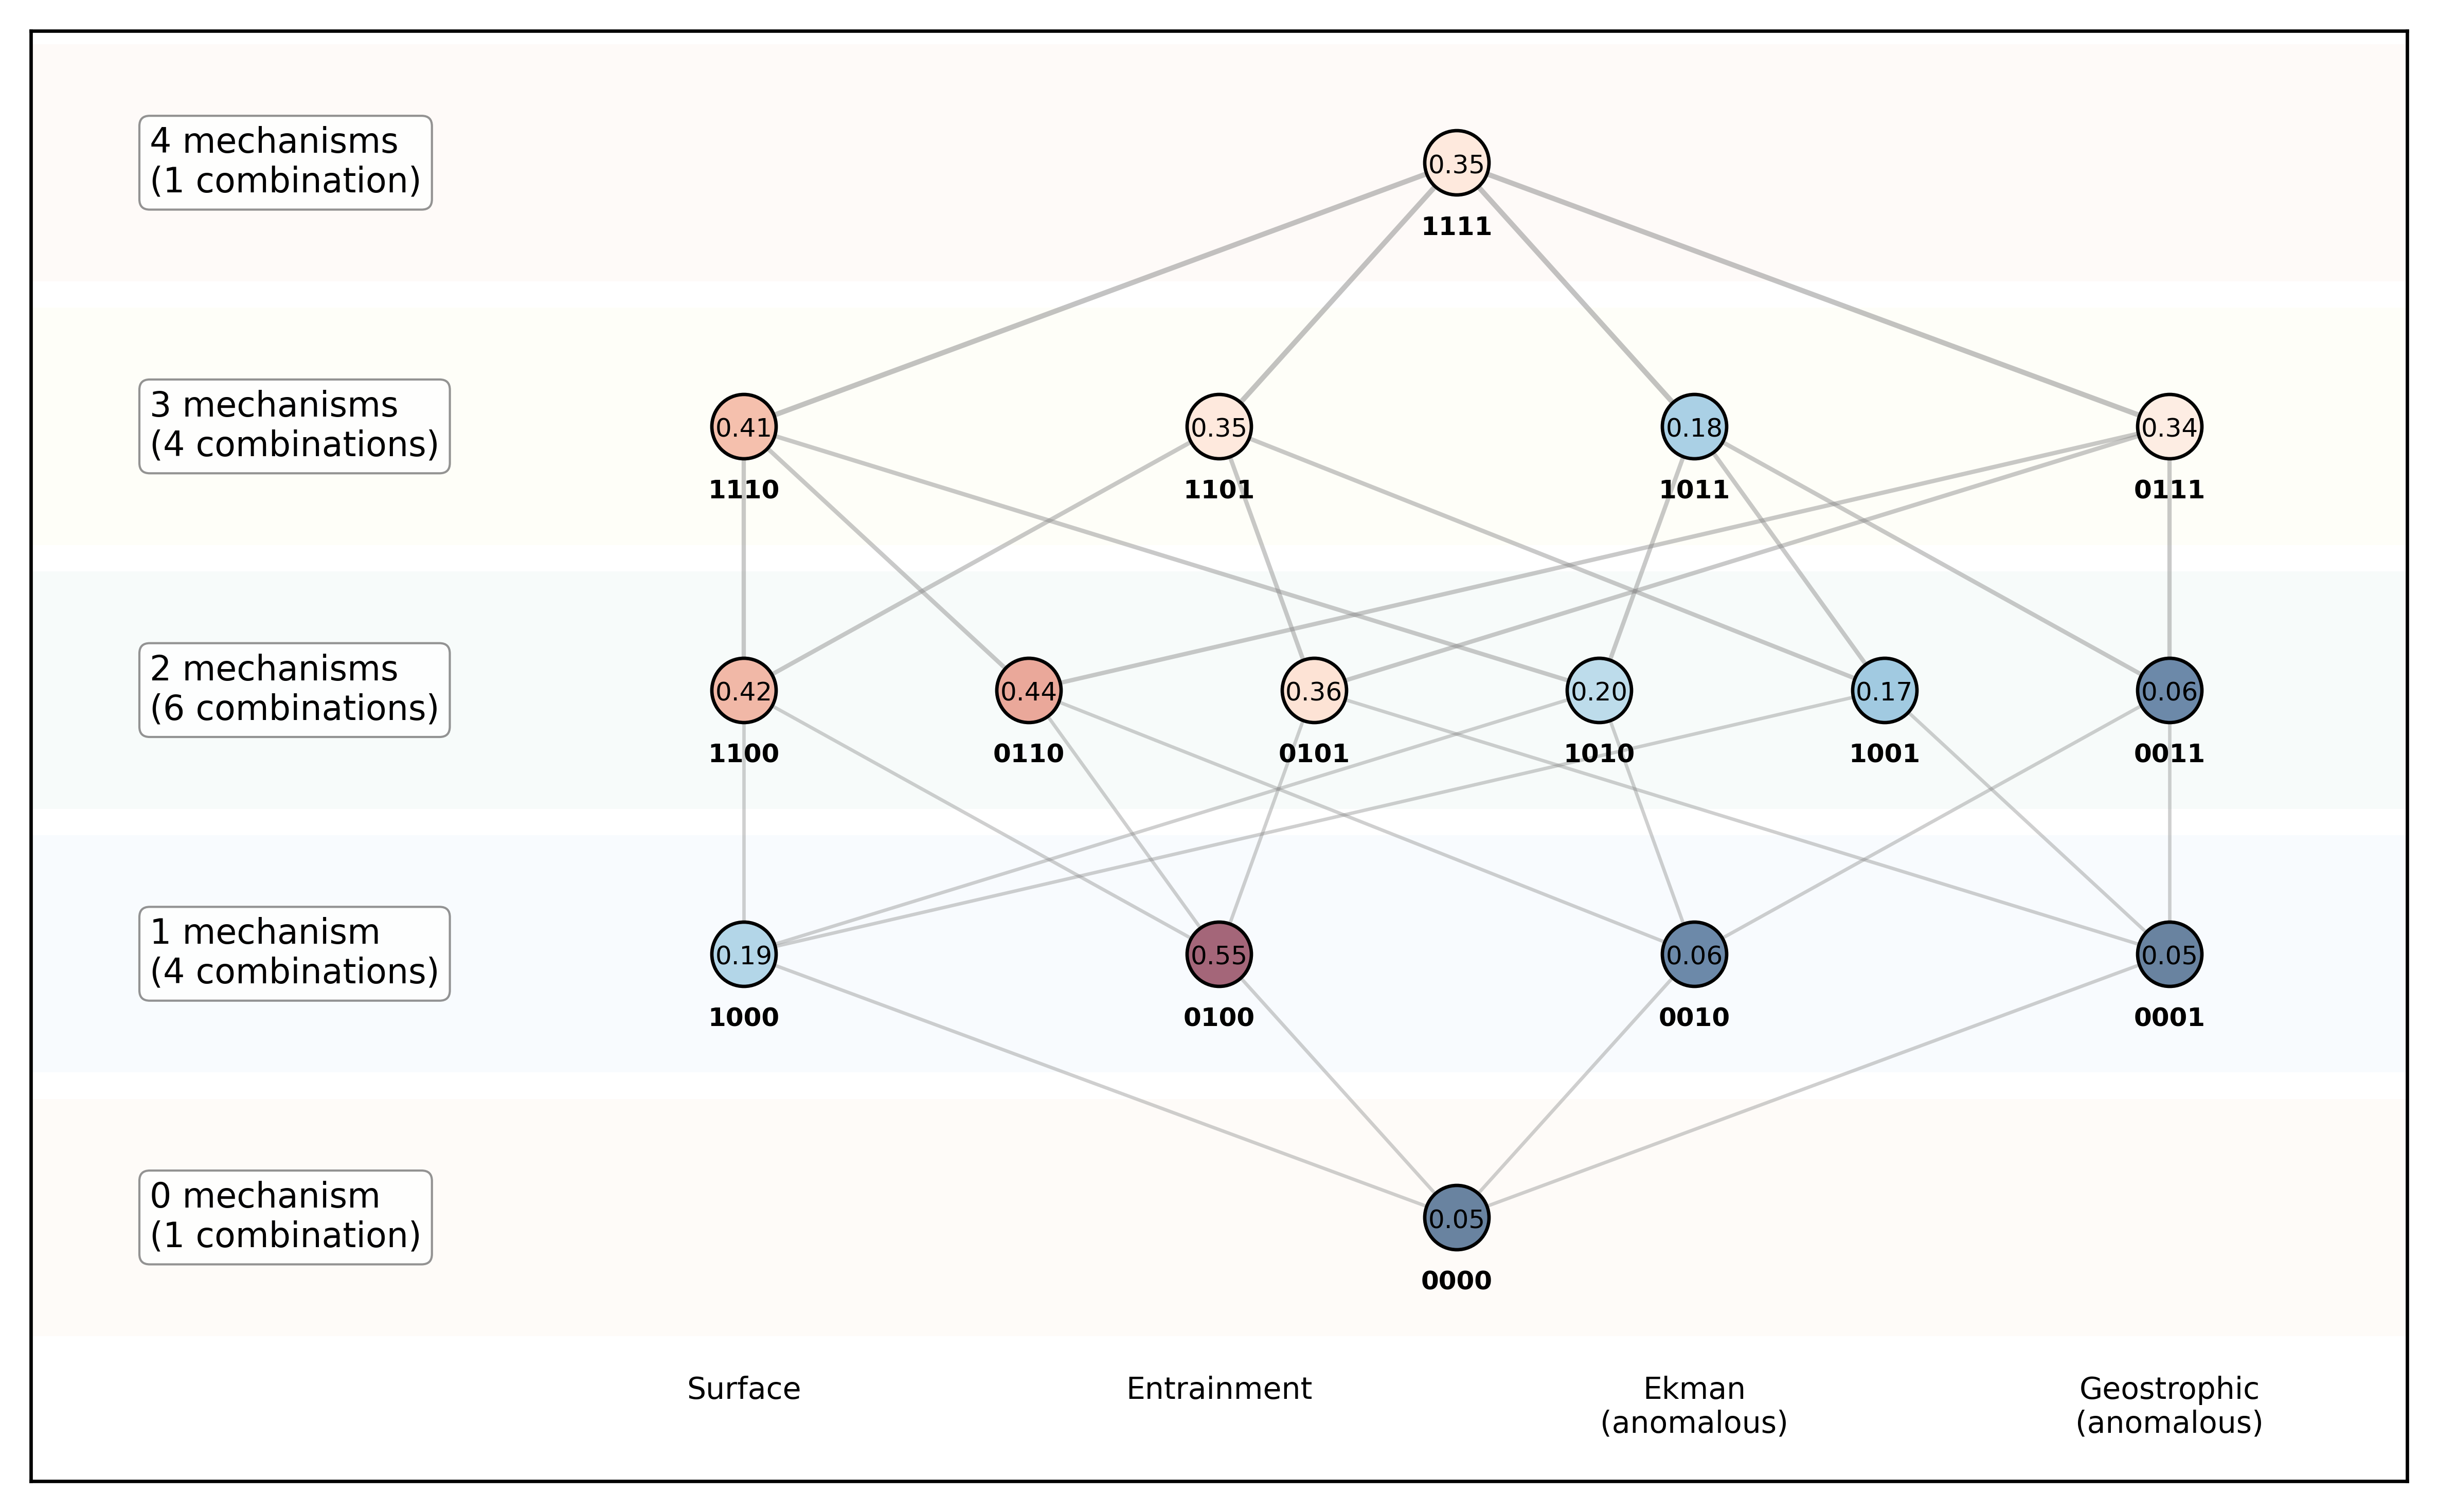

In [5]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=600)

level_facecolors = {
    0: '#FEF3E8',
    1: '#E8F4FC',
    2: '#E6F3EF',
    3: '#FEFCE8',
    4: '#FDF0E8'
}
level_titles = {
    0: '0 mechanism\n(1 combination)',
    1: '1 mechanism\n(4 combinations)',
    2: '2 mechanisms\n(6 combinations)',
    3: '3 mechanisms\n(4 combinations)',
    4: '4 mechanisms\n(1 combination)'
}

# Level 4 -> Level 3
for parent in level4_sorted:
    children = get_children(parent, level3_sorted)
    px, py = positions[parent]
    for child in children:
        cx, cy = positions[child]
        ax.plot([px, cx], [py, cy], '#888888', linewidth=1.2, alpha=0.5, zorder=1)
# Level 3 -> Level 2
for parent in level3_sorted:
    children = get_children(parent, level2_sorted)
    px, py = positions[parent]
    for child in children:
        cx, cy = positions[child]
        ax.plot([px, cx], [py, cy], '#888888', linewidth=1.0, alpha=0.45, zorder=1)
# Level 2 -> Level 1
for parent in level2_sorted:
    children = get_children(parent, level1_sorted)
    px, py = positions[parent]
    for child in children:
        cx, cy = positions[child]
        ax.plot([px, cx], [py, cy], '#888888', linewidth=0.8, alpha=0.4, zorder=1)
# Level 1 -> Level 0
for parent in level1_sorted:
    children = get_children(parent, level0_sorted)
    px, py = positions[parent]
    for child in children:
        cx, cy = positions[child]
        ax.plot([px, cx], [py, cy], '#888888', linewidth=0.8, alpha=0.4, zorder=1)

tree = {
    0: level0_sorted, 1: level1_sorted,
    2: level2_sorted, 3: level3_sorted,
    4: level4_sorted
}

corr_values = list(correlations.values())
cmap = cm.RdBu_r
norm = plt.Normalize(vmin=min(corr_values), vmax=max(corr_values))


def lighten_color(corr, cmap, norm, factor=0.5):
    """Lighten a color based on its correlation value"""
    color = cmap(norm(corr))
    return tuple(1 - (1 - c) * factor for c in color)


for level, combos in tree.items():
    y = level
    for combo in combos:
        x, y_pos = positions[combo]
        corr = correlations[combo]

        ax.plot(x, y_pos, 'o', markersize=15, 
                color=lighten_color(corr, cmap, norm, factor=0.6),
                markeredgecolor='black', 
                markeredgewidth=0.8,
                zorder=3)

        ax.text(
            x, y_pos-0.2, combo, 
            ha='center', va='top', 
            fontsize=6, fontweight='bold'
        )
        
        ax.text(
            x, y_pos-0.06, f'{corr:.2f}', 
            ha='center', va='bottom', 
            fontsize=6
            )

for level in range(0, 5):
    y_band = level
    ax.axhspan(
        y_band - 0.45, y_band + 0.45, 
        facecolor=level_facecolors[level], 
        alpha=0.3, zorder=0
    )

for level, title in level_titles.items():
    y_pos = level
    ax.text(
        -2.5, y_pos, title,
        ha='left', va='center', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.85, edgecolor='gray', linewidth=0.5)
    )

ax.set_xlim(-3, 7)
ax.set_ylim(-1, 4.5)
ax.set_xticks([])
ax.set_yticks([])
ax.set_xticklabels([])
for x, label in zip([0, 2, 4, 6], 
                    ['Surface', 'Entrainment',
                     'Ekman\n(anomalous)', 'Geostrophic\n(anomalous)']):
    ax.text(x, -0.6, label, ha='center', va='top', fontsize=7)

plt.tight_layout()
plt.show()